#### ============================================
###  1. Import Libraries
#### ============================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### ============================================
###  2. Read a Data
#### ============================================

In [4]:
Data = pd.read_csv('/Users/mac/Desktop/Zain Projects/Task 2 Visitor Mall Dataset/data/processed/total_visitors_per_mall_cleaned.csv')

#### ============================================
###  3. Check a Data
#### ============================================

In [5]:
Data.head()

,SUBSCRIBER_ID,VISIT_DATE,MALL_NAME,HOME_GOVERNORATE,WORK_GOVERNORATE,NATIONALITY,ARPU_BRACKET,DEVICE_OS,AGE_BRACKET,GENDER,STUDENT,IS_EMPLOYEE,CREDIT_CATEGORY,YEAR,DAY
0,11121,2022-11-08 13:18:15,Sunset Mall,Governorate 1,Governorate 1,Citizen,Low,iOS,> 25 and <= 45,Female,Not a student,0,Fair,2022,8
1,11122,2022-11-19 15:28:46,City Center Mall,Governorate 2,Governorate 2,Citizen,High,iOS,> 25 and <= 45,Male,Not a student,0,Excellent,2022,19
2,11122,2022-11-04 11:44:39,Sunset Mall,Governorate 2,Governorate 2,Citizen,High,iOS,> 25 and <= 45,Male,Not a student,0,Excellent,2022,4
3,11123,2022-11-05 14:52:57,City Center Mall,Governorate 1,Governorate 1,Citizen,Low,iOS,<= 18,Male,Not a student,0,Excellent,2022,5
4,11124,2022-11-07 17:43:37,Oasis Mall,Governorate 2,Governorate 2,Citizen,High,iOS,> 45,Male,Not a student,0,Excellent,2022,7


In [7]:
Data['VISIT_DATE'] = pd.to_datetime(Data['VISIT_DATE'])
Data['HOUR'] = Data['VISIT_DATE'].dt.hour
Data['WEEKDAY'] = Data['VISIT_DATE'].dt.day_name()

#### ============================================
###  4. Exploratory Data Analysis
#### ============================================

###  4.1 Total visits per mall

/var/folders/qp/phjgxp894ns8_sk2pqy1hqjh0000gn/T/ipykernel_17164/2270888186.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Data, y='MALL_NAME', order=order, palette='viridis')


Text(0, 0.5, 'Mall')

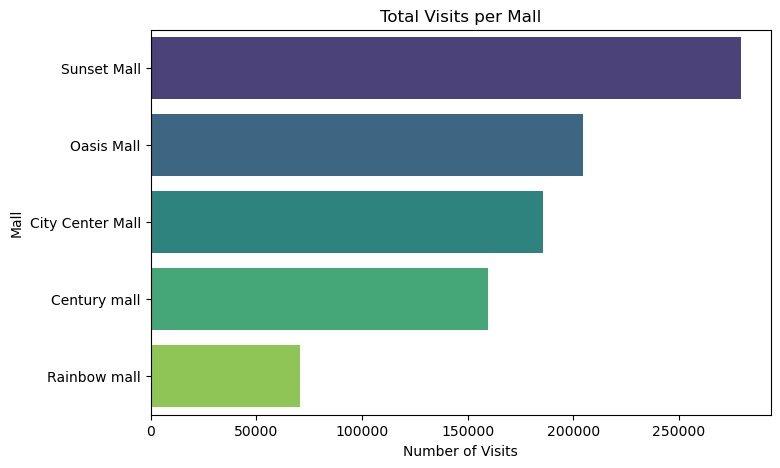

In [10]:
plt.figure(figsize=(8,5))
order = Data['MALL_NAME'].value_counts().index
sns.countplot(data=Data, y='MALL_NAME', order=order, palette='viridis')
plt.title('Total Visits per Mall')
plt.xlabel('Number of Visits'); plt.ylabel('Mall')

### Total Visits per Mall — Sunset Mall has the highest number of visits (~279K), followed by Oasis Mall (~204K), while Rainbow Mall has the lowest (~70K) — a notable ~4x gap between the highest and lowest mall. 

###  4.2 Visits by day of month

Text(0, 0.5, 'Number of Visits')

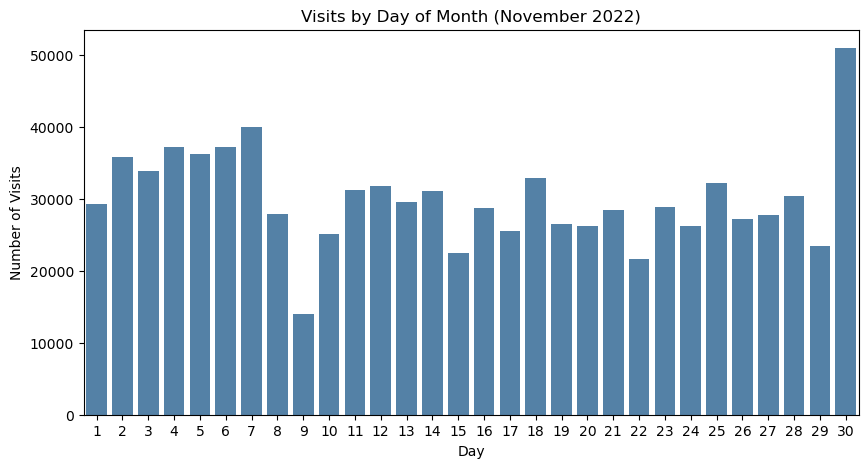

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(data=Data, x='DAY', color='steelblue')
plt.title('Visits by Day of Month (November 2022)')
plt.xlabel('Day'); plt.ylabel('Number of Visits')

### Visits by Day of Month — Day 30 (end of month) has the highest visit count (~51K), while day 9 has the lowest (~14K) — possibly linked to end-of-month/payday effects or a special event.

###  4.3 Visits by hour of day

Text(0, 0.5, 'Number of Visits')

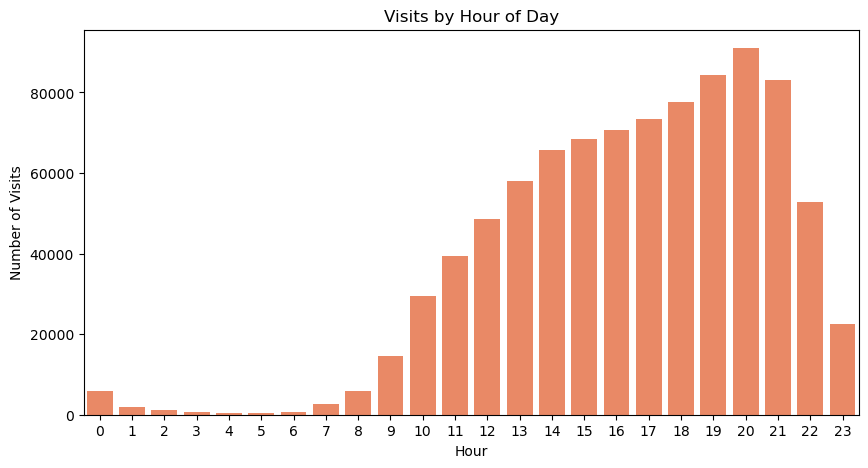

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(data=Data, x='HOUR', color='coral')
plt.title('Visits by Hour of Day')
plt.xlabel('Hour'); plt.ylabel('Number of Visits')

### Visits by Hour of Day — Peak activity occurs between 7-9 PM (highest at 8 PM with ~91K visits) — reflecting evening leisure time after work.

###  4.4 Visits by weekday

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Monday'),
  Text(1, 0, 'Tuesday'),
  Text(2, 0, 'Wednesday'),
  Text(3, 0, 'Thursday'),
  Text(4, 0, 'Friday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Sunday')])

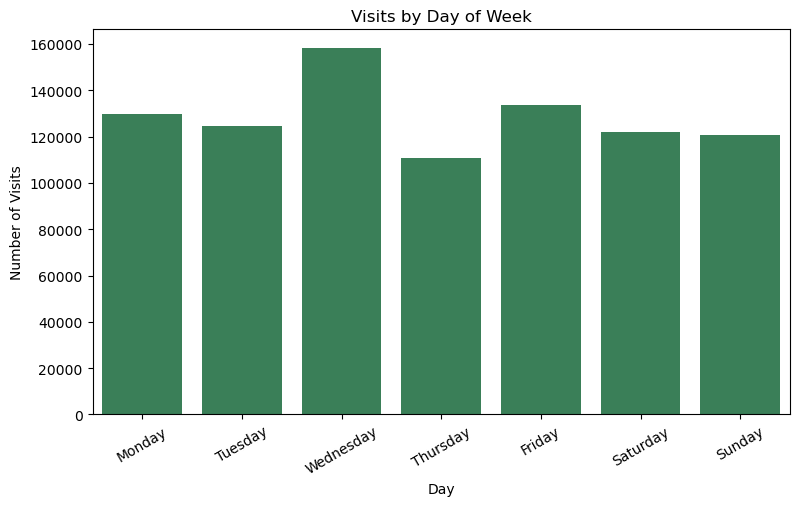

In [16]:
plt.figure(figsize=(9,5))
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.countplot(data=Data, x='WEEKDAY', order=order_days, color='seagreen')
plt.title('Visits by Day of Week')
plt.xlabel('Day'); plt.ylabel('Number of Visits')
plt.xticks(rotation=30)

### Visits by Weekday — Wednesday is notably the highest-traffic day (~158K), while Thursday is the lowest (~111K) — an unexpected pattern (not Friday/Saturday as typically expected).

###  4.5 Age bracket distribution

Text(0, 0.5, 'Number of Visits')

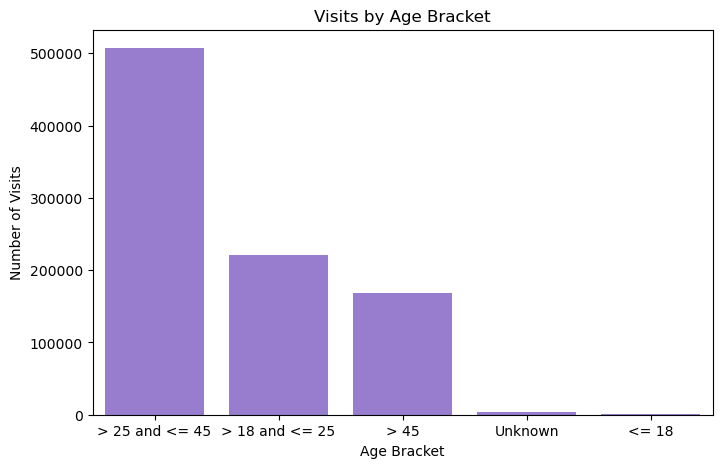

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(data=Data, x='AGE_BRACKET', order=Data['AGE_BRACKET'].value_counts().index, color='mediumpurple')
plt.title('Visits by Age Bracket')
plt.xlabel('Age Bracket'); plt.ylabel('Number of Visits')

### Age Bracket Distribution — The 25-45 age group makes up the vast majority of visitors (~507K out of ~899K), followed by the 18-25 group — indicating working-age adults are the primary target demographic.

###  4.6 Gender distribution per mall

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Sunset Mall'),
  Text(1, 0, 'City Center Mall'),
  Text(2, 0, 'Oasis Mall'),
  Text(3, 0, 'Century mall'),
  Text(4, 0, 'Rainbow mall')])

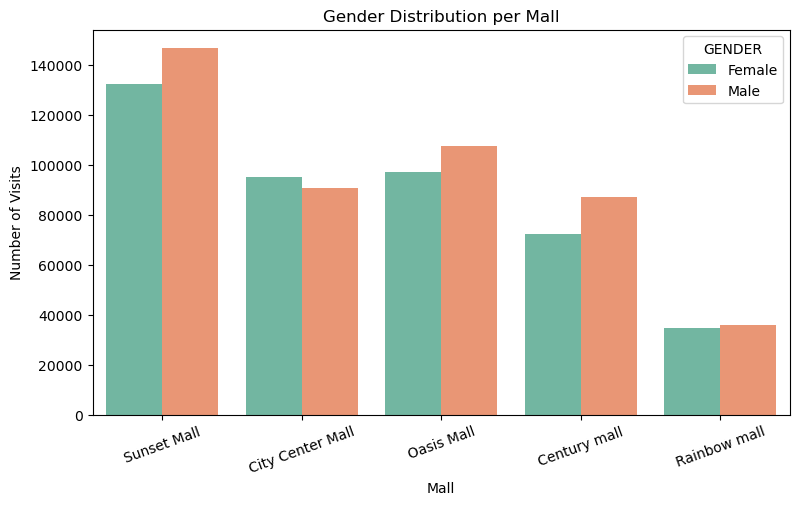

In [21]:
plt.figure(figsize=(9,5))
sns.countplot(data=Data, x='MALL_NAME', hue='GENDER', palette='Set2')
plt.title('Gender Distribution per Mall')
plt.xlabel('Mall'); plt.ylabel('Number of Visits')
plt.xticks(rotation=20)

### Gender per Mall — The distribution is fairly balanced between males (52%) and females (48%) across all malls, with no significant variation between malls.

###  4.7 ARPU bracket vs Mall (heatmap of proportions)

Text(70.72222222222221, 0.5, 'Mall')

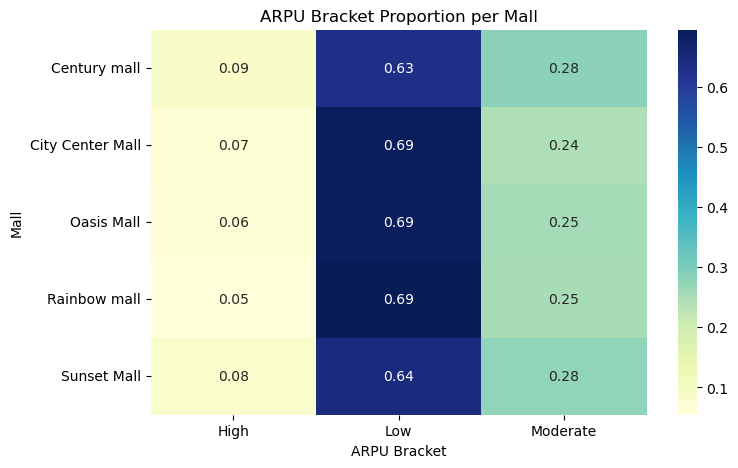

In [17]:
plt.figure(figsize=(8,5))
ct = pd.crosstab(Data['MALL_NAME'], Data['ARPU_BRACKET'], normalize='index')
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('ARPU Bracket Proportion per Mall')
plt.xlabel('ARPU Bracket'); plt.ylabel('Mall')

### ARPU Bracket per Mall (Heatmap) — The majority of visitors fall into the "Low" ARPU bracket (~63-69% across all malls), with Century Mall having the highest proportion of "High" ARPU visitors (~8.9%) compared to other malls.

###  4.8 Device OS distribution

Text(0, 0.5, '')

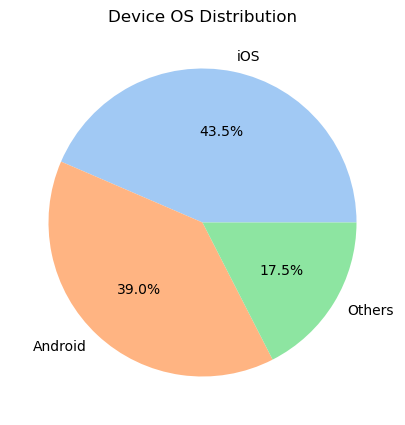

In [23]:
plt.figure(figsize=(7,5))
Data['DEVICE_OS'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Device OS Distribution')
plt.ylabel('')

### Device OS Distribution — iOS leads with 43.5%, followed by Android at 39%, and Others at 17.5% — indicating a relatively strong iOS customer base.